# B.O.S.S. — YOLOv8 Training

**Pipeline:**
1. Setup ambiente e librerie
2. Configurazione globale (modello, classi, percorsi)
3. Verifica struttura dataset (train / valid / test)
4. Generazione `data.yaml` per YOLOv8
5. Statistiche dataset pre-training
6. Training YOLOv8n
7. Esportazione modello (ONNX)

---
**Dataset:** `obstacle-detection-dataset` (Kaggle, già in formato YOLO).
**Nota:** La valutazione quantitativa è gestita separatamente in `boss_yolo_test.ipynb`.


In [1]:
import os, shutil
from pathlib import Path

IS_COLAB  = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False
IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_DIR = Path("/content/drive/MyDrive/Lavoro/code")
    os.chdir(WORK_DIR)
    print("Colab. Working dir:", os.getcwd())
elif IS_KAGGLE:
    WORK_DIR = Path("/kaggle/working")
    os.chdir(WORK_DIR)
    print("Kaggle. Working dir:", os.getcwd())
    print("Input disponibili:", list(Path("/kaggle/input").iterdir()))
else:
    print("Locale. Cella saltata.")


Kaggle. Working dir: /kaggle/working
Input disponibili: [PosixPath('/kaggle/input/datasets')]


## Cella 1 — Installazione dipendenze
Eseguire solo la prima volta o in un nuovo ambiente.

In [2]:
# Su Kaggle torch/torchvision/numpy/opencv sono preinstallati.
# Installa solo le librerie mancanti.
%pip install ultralytics pyyaml tqdm --quiet

# Su Colab o locale (torch non preinstallato), decommenta:
# %pip install torch torchvision --quiet
# %pip install ultralytics opencv-python Pillow matplotlib seaborn numpy pandas tqdm pyyaml --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


## Cella 2 — Import librerie

In [3]:
import os                         # operazioni su file e directory
import shutil                     # copia/spostamento file
import json                       # parsing file JSON generici
import glob                       # ricerca file con pattern
from pathlib import Path          # gestione percorsi cross-platform

import numpy as np                # operazioni su array e calcolo numerico
import pandas as pd               # strutture dati tabellari per metriche
import cv2                        # OpenCV: lettura/scrittura immagini, disegno
from PIL import Image             # Pillow: manipolazione immagini ad alto livello

import matplotlib.pyplot as plt   # grafici 2D (curve, bar chart)
import matplotlib.patches as mpatches  # elementi grafici personalizzati nei plot
import seaborn as sns             # heatmap e grafici statistici (confusion matrix)

from tqdm import tqdm             # barre di avanzamento per loop su dataset

from ultralytics import YOLO      # modello YOLOv8: training, val, predict

import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Cella 3 — Configurazione globale
**Modifica questa cella per cambiare modello, classi o percorsi.**

In [4]:
# ============================================================
# CONFIGURAZIONE — modifica questi valori per adattare la pipeline
# ============================================================

MODEL_PATH = "yolov8n.pt"

import torch
import yaml

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
if IS_KAGGLE:
    INPUT_DIR = Path("/kaggle/input")
    BASE_DIR  = Path("/kaggle/working")
else:
    INPUT_DIR = Path(".").resolve()
    BASE_DIR  = Path(".").resolve()

# ------------------------------------------------------------
# Nuovo dataset: 26-class Senior-Design-VIAD-4 (formato YOLO, già splittato)
# Struttura attesa:
#   <DATASET_ROOT>/
#       train/   (immagini + labels YOLO)
#       valid/   (immagini + labels YOLO)
#       test/    (immagini + labels YOLO)
#   data.yaml (opzionale, se fornito dall'autore del dataset)
# ------------------------------------------------------------
if IS_KAGGLE:
    DATASET_ROOT = Path(
        "/kaggle/input/datasets/abtinzandi/"
        "obstacle-detection-dataset/ROD-Dataset/dataset"
    )
else:
    DATASET_ROOT = BASE_DIR / "Senior-Design-VIAD-4"

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR  = DATASET_ROOT / "test"

# Directory di lavoro dove verrà scritto il data.yaml usato da YOLOv8
DATASET_DIR = BASE_DIR / "dataset_boss"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Class names: si tenta la lettura dinamica dal data.yaml originale del dataset.
# Se assente, si usa un fallback con le 26 classi VIAD-4 (placeholder generici
# che vanno sostituiti se la mappatura ufficiale è diversa).
# ------------------------------------------------------------
# Ricerca ricorsiva: trova tutti i data.yaml sotto /kaggle/input
_dataset_yaml_candidates = sorted(Path("/kaggle/input").rglob("data.yaml")) if IS_KAGGLE else [
    DATASET_ROOT / "data.yaml",
    DATASET_ROOT.parent / "data.yaml",
]
_loaded_yaml = None
for _yp in _dataset_yaml_candidates:
    if _yp.exists():
        with open(_yp) as _f:
            _loaded_yaml = yaml.safe_load(_f)
        print(f"Letto data.yaml originale: {_yp}")
        break

if _loaded_yaml is not None and "names" in _loaded_yaml:
    _names = _loaded_yaml["names"]
    if isinstance(_names, dict):
        # YOLOv8 formato dict: {0: 'classA', 1: 'classB', ...}
        BOSS_CLASSES = [_names[k] for k in sorted(_names.keys(), key=int)]
    else:
        BOSS_CLASSES = list(_names)
else:
    print("data.yaml del dataset non trovato — uso fallback a 26 classi generiche.")
    BOSS_CLASSES = [f"class_{i}" for i in range(26)]

NUM_CLASSES = len(BOSS_CLASSES)

# ------------------------------------------------------------
# Iperparametri di training
# ------------------------------------------------------------
EPOCHS        = 50
BATCH_SIZE    = 32
IMG_SIZE      = 640
LEARNING_RATE = 0.01
# Forza single GPU: DDP con 2 GPU su Kaggle prova a scrivere .cache in /kaggle/input (read-only)
DEVICE        = "0,1" if torch.cuda.is_available() else "cpu"
IOU_THRESHOLD = 0.45

print(f"Modello: {MODEL_PATH}")
print(f"Classi ({NUM_CLASSES}): {BOSS_CLASSES}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")
print(f"GPU disponibili: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"Device: {DEVICE}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"  train: {TRAIN_DIR}")
print(f"  valid: {VALID_DIR}")
print(f"  test:  {TEST_DIR}")


Letto data.yaml originale: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/data.yaml
Modello: yolov8n.pt
Classi (25): ['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree', 'Guard rail', 'Pedestrian crosswalk', 'Truck', 'Bus', 'Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']
CUDA disponibile: True
GPU disponibili: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Device: 0,1
Dataset root: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset
  train: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train
  valid: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid
  test:  /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/test


## Cella 4 — Verifica struttura dataset

**Su Kaggle:** il dataset `Senior-Design-VIAD-4` è già estratto in `/kaggle/input/...`.
Si verifica la presenza delle tre cartelle `train/`, `valid/`, `test/` e si conta il numero di immagini e label per ciascuna.


In [5]:
# Verifica dell'integrità strutturale del dataset.
# YOLOv8 si aspetta immagini e label nella stessa cartella (o in sottocartelle
# parallele `images/` e `labels/`). Il dataset VIAD-4 mette tutto nella stessa
# directory split (train/, valid/, test/), per cui si conteggiano direttamente
# i file per estensione.

IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp"}
LABEL_EXT  = ".txt"

def _count_dataset_split(split_dir: Path):
    if not split_dir.exists():
        return None
    # Cerca prima in <split>/images e <split>/labels (struttura "esplicita")
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"
    if img_dir.exists() and lbl_dir.exists():
        images = [p for p in img_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
        labels = list(lbl_dir.rglob(f"*{LABEL_EXT}"))
        return {"images": len(images), "labels": len(labels),
                "img_dir": img_dir, "lbl_dir": lbl_dir}
    # Altrimenti: immagini e label mescolate nella stessa cartella
    images = [p for p in split_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
    labels = list(split_dir.rglob(f"*{LABEL_EXT}"))
    return {"images": len(images), "labels": len(labels),
            "img_dir": split_dir, "lbl_dir": split_dir}

for name, sd in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    info = _count_dataset_split(sd)
    if info is None:
        print(f"MANCANTE  {name}: {sd}")
    else:
        print(f"OK  {name}: {sd}")
        print(f"     immagini: {info['images']:>6}  | label: {info['labels']:>6}")
        print(f"     img_dir : {info['img_dir']}")
        print(f"     lbl_dir : {info['lbl_dir']}")


OK  train: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train
     immagini:  19186  | label:  19186
     img_dir : /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train/images
     lbl_dir : /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train/labels
OK  valid: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid
     immagini:   3511  | label:   3511
     img_dir : /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid/images
     lbl_dir : /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid/labels
OK  test: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/test
     immagini:   1629  | label:   1629
     img_dir : /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/test/images
     lbl_dir : /kaggle/input/datasets/abtinzand

In [6]:
# DIAGNOSTICA: mostra la struttura effettiva del dataset per verificare
# il formato delle annotazioni (YOLO .txt vs COCO JSON, ecc.)
import subprocess

print("=== Contenuto DATASET_ROOT (primi 2 livelli) ===")
for p in sorted(DATASET_ROOT.rglob("*")):
    depth = len(p.relative_to(DATASET_ROOT).parts)
    if depth <= 2:
        indent = "  " * (depth - 1)
        size = p.stat().st_size if p.is_file() else ""
        print(f"{indent}{p.name}  {'(' + str(size) + ' B)' if size != '' else '[dir]'}")

print("\n=== Estensioni file nel dataset ===")
from collections import Counter
exts = Counter(p.suffix.lower() for p in DATASET_ROOT.rglob("*") if p.is_file())
for ext, count in sorted(exts.items(), key=lambda x: -x[1]):
    print(f"  {ext or '(no ext)':15s}: {count}")


=== Contenuto DATASET_ROOT (primi 2 livelli) ===
class_distribution.csv  (796 B)
data.yaml  (386 B)
images_manifest.csv  (1193764 B)
rename_map.csv  (1928849 B)
test  [dir]
  images  [dir]
  labels  [dir]
train  [dir]
  images  [dir]
  labels  [dir]
valid  [dir]
  images  [dir]
  labels  [dir]

=== Estensioni file nel dataset ===
  .txt           : 24326
  .jpg           : 24326
  .csv           : 3
  .yaml          : 1


## Cella 5 — Creazione file `data.yaml` per YOLOv8


In [7]:
# Genera il file data.yaml richiesto da YOLOv8 per il training.
# Punta direttamente al dataset Kaggle, senza copia locale.
# YOLOv8 risolve i path `train/val/test` come relativi al campo `path`.

import yaml

data_yaml = {
    "path":  str(DATASET_ROOT),   # root del dataset Kaggle
    "train": "train/images",      # cartella immagini di training
    "val":   "valid/images",      # cartella immagini di validazione
    "test":  "test/images",       # cartella immagini di test
    "nc":    NUM_CLASSES,         # numero di classi
    "names": BOSS_CLASSES,        # lista nomi classi
}

yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml scritto in: {yaml_path}")
print(yaml.dump(data_yaml, default_flow_style=False))


data.yaml scritto in: /kaggle/working/dataset_boss/data.yaml
names:
- Bike
- Building
- Car
- Person
- Stairs
- Traffic sign
- Electrical Pole
- Road
- Motorcycle
- Dustbin
- Dog
- Manhole
- Tree
- Guard rail
- Pedestrian crosswalk
- Truck
- Bus
- Bench
- Traffic Cone
- Fire hydrant
- Teraffic Barrel
- Plant Pot
- Electrical Box
- Chair
- Bicycle Rack
nc: 25
path: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset
test: test/images
train: train/images
val: valid/images



## Cella 6 — Statistiche dataset pre-training


              Classe  Train  Val  Test  Totale
                Bike    323   95    49     467
            Building    886  101    54    1041
                 Car   4328 1003   247    5578
              Person   7609 1033   320    8962
              Stairs   1125  339   223    1687
        Traffic sign    689  114   104     907
     Electrical Pole    491   85    42     618
                Road    561   84    37     682
          Motorcycle    888   82    37    1007
             Dustbin   1351  153    45    1549
                 Dog    633   65    30     728
             Manhole   1779  480   242    2501
                Tree   1632  293   150    2075
          Guard rail   1385  131    69    1585
Pedestrian crosswalk   1875  429   189    2493
               Truck    621  159    43     823
                 Bus   1009  150    55    1214
               Bench    706   40    28     774
        Traffic Cone    678  171    92     941
        Fire hydrant    205   25    25     255
     Teraffic

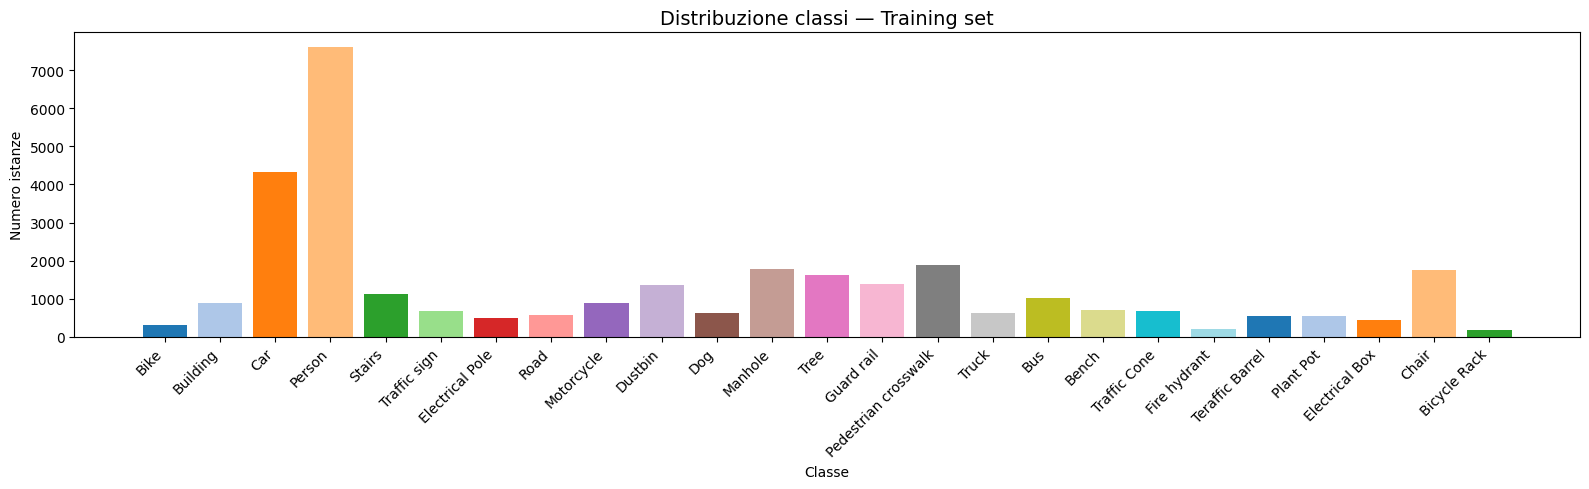

In [8]:
# Analizza la distribuzione delle classi nel dataset prima del training.
# Importante per individuare class imbalance che potrebbe degradare le performance.

def count_class_distribution(split_dir: Path):
    """
    Conta le occorrenze di ogni classe in tutti i file .txt YOLO del split.
    Gestisce sia la struttura piatta (label nella stessa cartella delle immagini)
    sia la struttura `labels/` separata.
    """
    counts = {i: 0 for i in range(NUM_CLASSES)}
    if not split_dir.exists():
        return counts

    lbl_dir = split_dir / "labels" if (split_dir / "labels").exists() else split_dir
    label_files = list(lbl_dir.rglob("*.txt"))

    for lf in label_files:
        try:
            text = lf.read_text().strip()
        except Exception:
            continue
        for line in text.split("\n"):
            line = line.strip()
            if not line:
                continue
            try:
                class_id = int(line.split()[0])
            except (ValueError, IndexError):
                continue
            if class_id in counts:
                counts[class_id] += 1
    return counts


train_counts = count_class_distribution(TRAIN_DIR)
val_counts   = count_class_distribution(VALID_DIR)
test_counts  = count_class_distribution(TEST_DIR)

# Costruisce DataFrame per visualizzazione tabellare
df_dist = pd.DataFrame({
    "Classe": BOSS_CLASSES,
    "Train":  [train_counts[i] for i in range(NUM_CLASSES)],
    "Val":    [val_counts[i]   for i in range(NUM_CLASSES)],
    "Test":   [test_counts[i]  for i in range(NUM_CLASSES)],
})
df_dist["Totale"] = df_dist["Train"] + df_dist["Val"] + df_dist["Test"]

print(df_dist.to_string(index=False))

# Grafico a barre della distribuzione delle classi nel training set
fig, ax = plt.subplots(figsize=(16, 5))
colors = plt.cm.tab20.colors * ((NUM_CLASSES // 20) + 1)
bars = ax.bar(BOSS_CLASSES, df_dist["Train"], color=colors[:NUM_CLASSES])
ax.set_title("Distribuzione classi — Training set", fontsize=14)
ax.set_xlabel("Classe")
ax.set_ylabel("Numero istanze")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(BASE_DIR / "plot_class_distribution.png", dpi=150)
plt.show()


## Cella 7 — Training YOLOv8
Il training salva automaticamente i pesi migliori in `runs/detect/boss_yolo/weights/best.pt`.

In [9]:
#=== TRAINING COMPLETATO — cella commentata ===
# Fine-tuning del modello YOLOv8 sul dataset B.O.S.S.
# Tutti i parametri sono configurabili nella cella 3.

# Per riprendere un training interrotto: imposta RESUME = True
# YOLOv8 carica last.pt e continua dalle epoche rimanenti
RESUME = True

if IS_KAGGLE and RESUME:
    LAST_PT = Path("/kaggle/working/runs/detect/boss_yolo/weights/last.pt") #DA MODIFICARE PATH
    print(f"Checkpoint: {LAST_PT} — esiste: {LAST_PT.exists()}")
else:
    LAST_PT = BASE_DIR / "runs/detect/boss_yolo/weights/last.pt"

if RESUME and LAST_PT.exists():
    print(f"Riprendendo training da: {LAST_PT}")
    model = YOLO(str(LAST_PT))
    results_train = model.train(resume=True)
else:
    if RESUME:
        print("ATTENZIONE: last.pt non trovato — controlla di aver aggiunto il model al notebook.")
    model = YOLO(MODEL_PATH)   # carica il modello di partenza (pre-trained su COCO)
    results_train = model.train(
        data      = str(yaml_path),      # file data.yaml con percorsi e classi
        epochs    = EPOCHS,              # numero di epoche di training
        batch     = BATCH_SIZE,          # immagini per batch
        imgsz     = IMG_SIZE,            # risoluzione input (640x640)
        lr0       = LEARNING_RATE,       # learning rate iniziale
        device    = DEVICE,              # GPU/CPU
        name      = "boss_yolo",         # nome cartella di output in runs/detect/
        patience  = 15,                  # early stopping: ferma se val/mAP non migliora per 15 epoche
        save      = True,                # salva best.pt e last.pt dopo ogni epoca
        plots     = True,                # genera grafici training automaticamente
        verbose   = True,
        cache     = False,               # evita scrittura .cache in /kaggle/input (read-only)
    )

BEST_MODEL_PATH = Path(results_train.save_dir) / "weights" / "best.pt"
print(f"Modello migliore: {BEST_MODEL_PATH}")
print(f"Esiste: {BEST_MODEL_PATH.exists()}")


Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_boss/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=boss_yolo, 

W0526 11:27:51.994000 129 torch/distributed/elastic/agent/server/api.py:739] Received 2 death signal, shutting down workers
W0526 11:27:51.995000 129 torch/distributed/elastic/multiprocessing/api.py:1010] Sending process 132 closing signal SIGINT
W0526 11:27:51.999000 129 torch/distributed/elastic/multiprocessing/api.py:1010] Sending process 133 closing signal SIGINT
[rank0]: Traceback (most recent call last):
[rank0]:   File "/root/.config/Ultralytics/DDP/_temp_funp3gj2138142909035584.py", line 19, in <module>
[rank0]:     results = trainer.train()
[rank0]:               ^^^^^^^^^^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 246, in train
[rank0]:     self._do_train()
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 459, in _do_train
[rank0]:     self.scaler.scale(self.loss).backward()
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 630, in backward
[ran

      12/50      3.36G      1.007      1.057      1.364         16        640: 92% ━━━━━━━━━━╸─ 549/600 4.9it/s 3:14<10.4s


KeyboardInterrupt: 

## Cella 7b — Recupero path modello dopo training

In [ ]:
import glob as _glob

# Cerca prima nella working dir (se il training è stato eseguito in questa sessione)
found_pts = _glob.glob('/kaggle/working/runs/detect/**/weights/*.pt', recursive=True)
for p in sorted(found_pts):
    print(p)

best_candidates = [p for p in found_pts if p.endswith('best.pt')]

if best_candidates:
    BEST_MODEL_PATH = Path(best_candidates[0])
    print(f"\nBEST_MODEL_PATH (da working): {BEST_MODEL_PATH}")
else:
    # Fallback: carica dal dataset Kaggle con i pesi salvati
    CHECKPOINT_DIR = Path("/kaggle/input/models/lorenzoverdura/boss-yolo-checkpoint/pytorch/default/1")
    best_ckpt = CHECKPOINT_DIR / "best.pt"
    last_ckpt = CHECKPOINT_DIR / "last.pt"

    if best_ckpt.exists():
        BEST_MODEL_PATH = best_ckpt
        print(f"\nBEST_MODEL_PATH (da checkpoint dataset): {BEST_MODEL_PATH}")
    elif last_ckpt.exists():
        BEST_MODEL_PATH = last_ckpt
        print(f"\nBEST_MODEL_PATH (last.pt da checkpoint dataset): {BEST_MODEL_PATH}")
    else:
        raise FileNotFoundError(
            f"Nessun .pt trovato né in working né in {CHECKPOINT_DIR}. "
            "Esegui il training oppure verifica che il dataset boss-yolo-checkpoint sia allegato."
        )


## Cella 8 — Esportazione modello (ONNX)

Esporta `best.pt` in formato **ONNX** per il deployment su dispositivo Edge (Jetson, OpenVINO, ONNX Runtime).

- `simplify=True`: ottimizza il grafo rimuovendo operatori ridondanti
- `opset=12`: compatibile con TensorRT 8+ e la maggior parte dei runtime Edge
- `dynamic=False`: dimensioni fisse per massima ottimizzazione hardware

Il file `.onnx` viene salvato nella stessa cartella di `best.pt`.

In [ ]:
# # ============================================================
# # Cella 8 — Esportazione modello in formato ONNX
# # ============================================================
# export_model = YOLO(str(BEST_MODEL_PATH))

# onnx_path = export_model.export(
#     format   = "onnx",
#     imgsz    = IMG_SIZE,
#     dynamic  = False,   # dimensioni input fisse per ottimizzazione hardware
#     simplify = True,    # semplifica il grafo ONNX (rimuove operatori ridondanti)
#     opset    = 12,      # compatibile con TensorRT 8+ e ONNX Runtime
# )

# print(f"Modello esportato: {onnx_path}")